In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [2]:
# Load dataset
df = pd.read_csv(r"C:\Users\Neethu\Documents\ML\brca.csv")

# Display first 5 rows
df.head()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           569 non-null    int64  
 1   x.radius_mean        569 non-null    float64
 2   x.texture_mean       569 non-null    float64
 3   x.perimeter_mean     569 non-null    float64
 4   x.area_mean          569 non-null    float64
 5   x.smoothness_mean    569 non-null    float64
 6   x.compactness_mean   569 non-null    float64
 7   x.concavity_mean     569 non-null    float64
 8   x.concave_pts_mean   569 non-null    float64
 9   x.symmetry_mean      569 non-null    float64
 10  x.fractal_dim_mean   569 non-null    float64
 11  x.radius_se          569 non-null    float64
 12  x.texture_se         569 non-null    float64
 13  x.perimeter_se       569 non-null    float64
 14  x.area_se            569 non-null    float64
 15  x.smoothness_se      569 non-null    float64
 16  x

In [4]:
df.describe()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,285.000000,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,164.400426,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,1.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,143.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,285.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,427.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,569.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [5]:
print(df.isnull().sum())

Unnamed: 0             0
x.radius_mean          0
x.texture_mean         0
x.perimeter_mean       0
x.area_mean            0
x.smoothness_mean      0
x.compactness_mean     0
x.concavity_mean       0
x.concave_pts_mean     0
x.symmetry_mean        0
x.fractal_dim_mean     0
x.radius_se            0
x.texture_se           0
x.perimeter_se         0
x.area_se              0
x.smoothness_se        0
x.compactness_se       0
x.concavity_se         0
x.concave_pts_se       0
x.symmetry_se          0
x.fractal_dim_se       0
x.radius_worst         0
x.texture_worst        0
x.perimeter_worst      0
x.area_worst           0
x.smoothness_worst     0
x.compactness_worst    0
x.concavity_worst      0
x.concave_pts_worst    0
x.symmetry_worst       0
x.fractal_dim_worst    0
y                      0
dtype: int64


In [7]:
print(df.columns)

Index(['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean',
       'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean',
       'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean',
       'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se',
       'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se',
       'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se',
       'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst',
       'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst',
       'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst',
       'x.fractal_dim_worst', 'y'],
      dtype='str')


In [9]:
print(df.columns.tolist())

['x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean', 'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean', 'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se', 'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se', 'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se', 'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst', 'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst', 'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst', 'x.fractal_dim_worst', 'y']


In [10]:
# Features
X = df.drop("y", axis=1)

# Target
y = df["y"]

# Convert target to numeric if needed
if y.dtype == "object":
    y = y.map({"M": 1, "B": 0})

print(X.shape)
print(y.shape)
print(y.unique())

(569, 30)
(569,)
<ArrowStringArray>
['B', 'M']
Length: 2, dtype: str


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
from sklearn.model_selection import train_test_split

X_train80, X_test80, y_train80, y_test80 = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [13]:
import numpy as np

n = len(X_train80)

k = int(np.sqrt(n))

# K should preferably be odd
if k % 2 == 0:
    k += 1

print("Training Samples:", n)
print("Heuristic K:", k)

Training Samples: 455
Heuristic K: 21


In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=k)

knn.fit(X_train80, y_train80)

prediction = knn.predict(X_test80)

print("Accuracy:", accuracy_score(y_test80, prediction))

Accuracy: 0.9385964912280702


In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = []
accuracies = []

# Try K values from 1 to 20
for k in range(1, 21):

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train80, y_train80)

    y_pred = model.predict(X_test80)

    acc = accuracy_score(y_test80, y_pred)

    k_values.append(k)
    accuracies.append(acc)

    print("K =", k, " Accuracy =", round(acc, 4))

# Best K
best_k = k_values[accuracies.index(max(accuracies))]
best_accuracy = max(accuracies)

print("\nBest K =", best_k)
print("Best Accuracy =", round(best_accuracy, 4))

K = 1  Accuracy = 0.9298
K = 2  Accuracy = 0.9123
K = 3  Accuracy = 0.9386
K = 4  Accuracy = 0.9386
K = 5  Accuracy = 0.9561
K = 6  Accuracy = 0.9474
K = 7  Accuracy = 0.9561
K = 8  Accuracy = 0.9474
K = 9  Accuracy = 0.9474
K = 10  Accuracy = 0.9474
K = 11  Accuracy = 0.9474
K = 12  Accuracy = 0.9474
K = 13  Accuracy = 0.9474
K = 14  Accuracy = 0.9386
K = 15  Accuracy = 0.9386
K = 16  Accuracy = 0.9386
K = 17  Accuracy = 0.9386
K = 18  Accuracy = 0.9386
K = 19  Accuracy = 0.9386
K = 20  Accuracy = 0.9386

Best K = 5
Best Accuracy = 0.9561


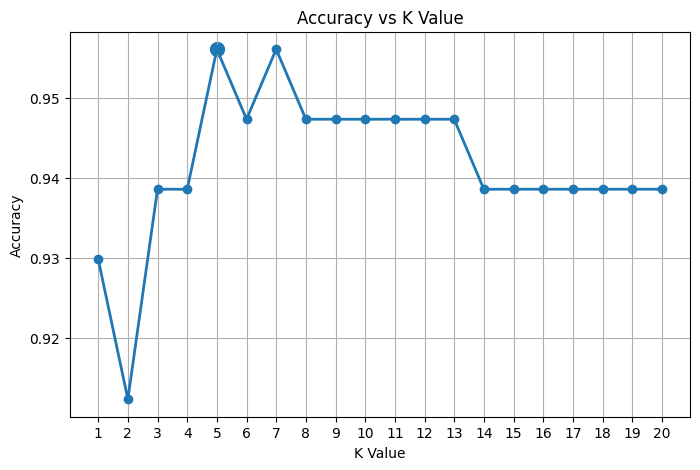

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(k_values, accuracies, marker='o', linewidth=2)

plt.scatter(best_k, best_accuracy, s=100)

plt.title("Accuracy vs K Value")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.xticks(range(1, 21))
plt.grid(True)

plt.show()

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

Confusion Matrix:
[[71  1]
 [ 6 36]]


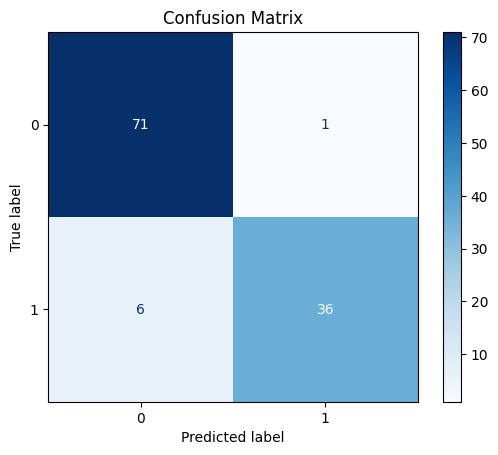

In [18]:
# Predict using the trained KNN model
y_pred = knn.predict(X_test80)

# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test80, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [19]:
print(type(knn))

<class 'sklearn.neighbors._classification.KNeighborsClassifier'>


In [20]:
print(y.unique())

<ArrowStringArray>
['B', 'M']
Length: 2, dtype: str


In [21]:
# Convert labels to numeric
y_numeric = y.map({'B': 0, 'M': 1})

print(y_numeric.unique())

[0 1]


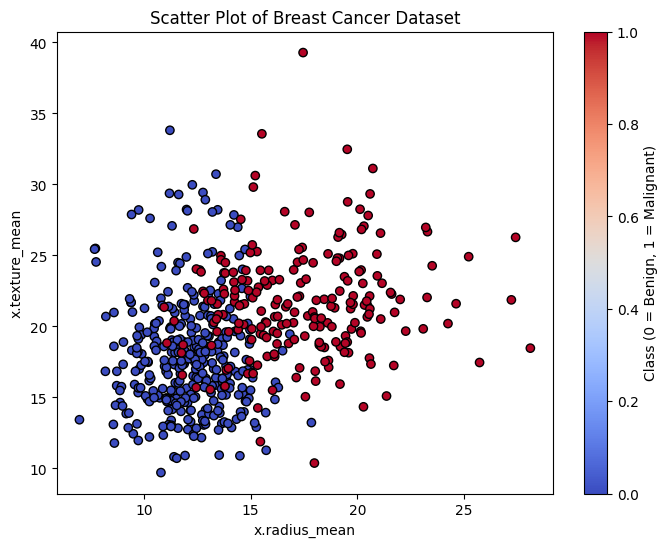

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=y_numeric,
    cmap='coolwarm',
    edgecolor='k'
)

plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("Scatter Plot of Breast Cancer Dataset")

plt.colorbar(label="Class (0 = Benign, 1 = Malignant)")

plt.show()

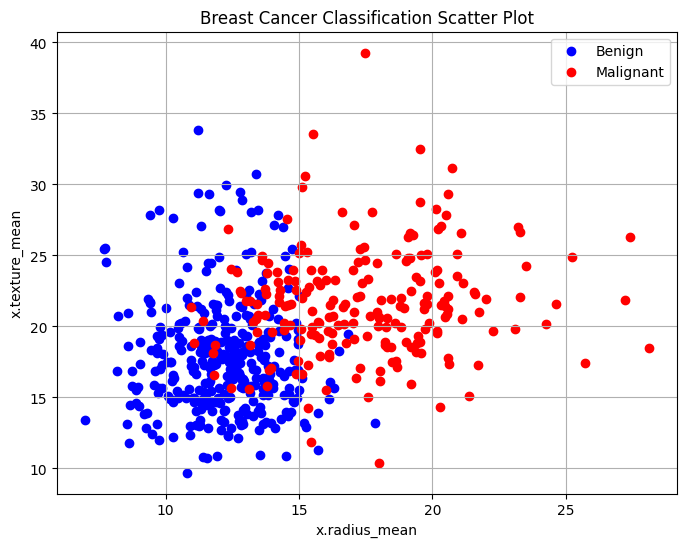

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Benign
plt.scatter(
    X[y == 'B'].iloc[:,0],
    X[y == 'B'].iloc[:,1],
    color='blue',
    label='Benign'
)

# Malignant
plt.scatter(
    X[y == 'M'].iloc[:,0],
    X[y == 'M'].iloc[:,1],
    color='red',
    label='Malignant'
)

plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("Breast Cancer Classification Scatter Plot")

plt.legend()

plt.grid(True)

plt.show()

In [25]:
X_train70, X_test70, y_train70, y_test70 = train_test_split(
    X_scaled,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

knn70 = KNeighborsClassifier(n_neighbors=best_k)
knn70.fit(X_train70, y_train70)

pred70 = knn70.predict(X_test70)

print("70:30 Accuracy =", accuracy_score(y_test70, pred70))

70:30 Accuracy = 0.9649122807017544


In [26]:
X_train90, X_test90, y_train90, y_test90 = train_test_split(
    X_scaled,
    y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

knn90 = KNeighborsClassifier(n_neighbors=best_k)
knn90.fit(X_train90, y_train90)

pred90 = knn90.predict(X_test90)

print("90:10 Accuracy =", accuracy_score(y_test90, pred90))

90:10 Accuracy = 0.9649122807017544


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test80, y_pred))
print("Precision :", precision_score(y_test80, y_pred, pos_label='M'))
print("Recall :", recall_score(y_test80, y_pred, pos_label='M'))
print("F1 Score :", f1_score(y_test80, y_pred, pos_label='M'))

Accuracy : 0.9385964912280702
Precision : 0.972972972972973
Recall : 0.8571428571428571
F1 Score : 0.9113924050632911


In [30]:
# Convert target labels
y = df["y"].map({'B': 0, 'M': 1})

print(y.unique())

[0 1]


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [32]:
from sklearn.model_selection import train_test_split

X_train80, X_test80, y_train80, y_test80 = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [33]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train80, y_train80)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [34]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train80, y_train80)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [35]:
y_pred = knn.predict(X_test80)

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test80, y_pred))
print("Precision :", precision_score(y_test80, y_pred))
print("Recall :", recall_score(y_test80, y_pred))
print("F1 Score :", f1_score(y_test80, y_pred))

Accuracy : 0.956140350877193
Precision : 0.9743589743589743
Recall : 0.9047619047619048
F1 Score : 0.9382716049382716


In [38]:
# Select first two features
X_boundary = df.iloc[:, 0:2]

# Convert target to numeric
y_boundary = df["y"].map({'B':0,'M':1})

# Scale the features
scaler = StandardScaler()
X_boundary = scaler.fit_transform(X_boundary)

In [ ]:

def plot_decision_boundary(k):

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_boundary, y_boundary)

    x_min, x_max = X_boundary[:,0].min()-1, X_boundary[:,0].max()+1
    y_min, y_max = X_boundary[:,1].min()-1, X_boundary[:,1].max()+1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,5))

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

    plt.scatter(X_boundary[:,0], X_boundary[:,1],
                c=y_boundary,
                cmap='coolwarm',
                edgecolors='k')

    plt.title(f"Decision Boundary (K = {k})")

    plt.xlabel(df.columns[0])

    plt.ylabel(df.columns[1])

    plt.show()

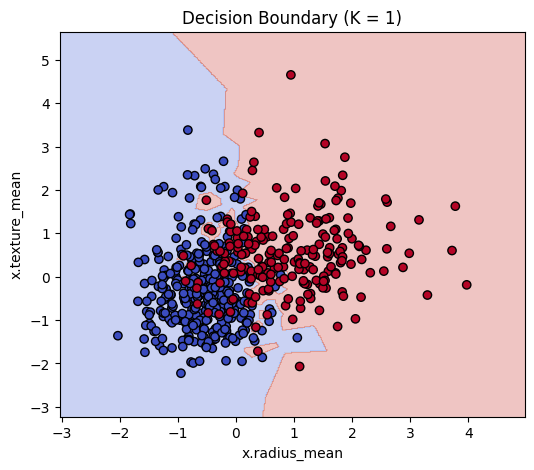

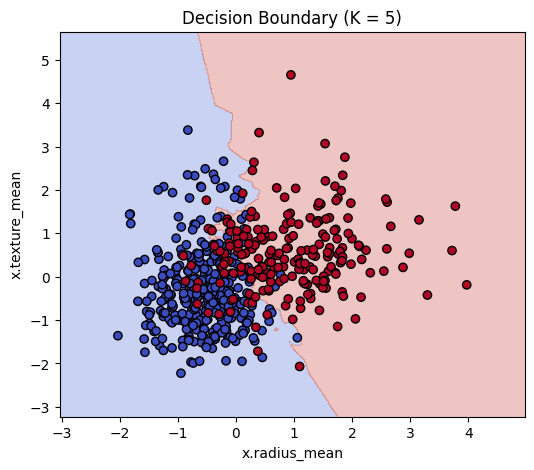

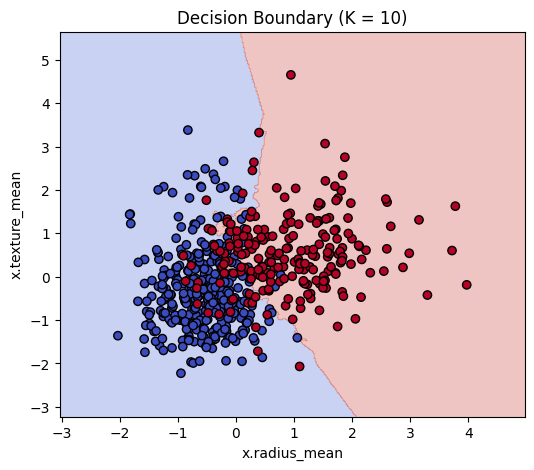

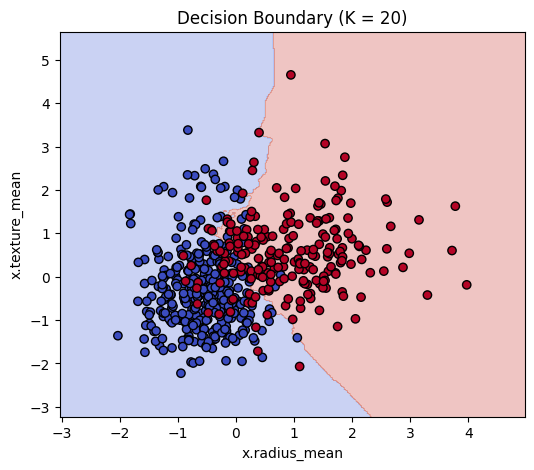

In [40]:
plot_decision_boundary(1)
plot_decision_boundary(5)
plot_decision_boundary(10)
plot_decision_boundary(20)

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
    
cv_scores = []

k_range = range(1,21)

for k in k_range:

    model = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(model,
                             X_scaled,
                             y,
                             cv=5,
                             scoring='accuracy')

    cv_scores.append(scores.mean())

    print("K =", k,
          "Mean Accuracy =", round(scores.mean(),4))

K = 1 Mean Accuracy = 0.9508
K = 2 Mean Accuracy = 0.9543
K = 3 Mean Accuracy = 0.9578
K = 4 Mean Accuracy = 0.9631
K = 5 Mean Accuracy = 0.9649
K = 6 Mean Accuracy = 0.9666
K = 7 Mean Accuracy = 0.9684
K = 8 Mean Accuracy = 0.9666
K = 9 Mean Accuracy = 0.9684
K = 10 Mean Accuracy = 0.9649
K = 11 Mean Accuracy = 0.9631
K = 12 Mean Accuracy = 0.9614
K = 13 Mean Accuracy = 0.9666
K = 14 Mean Accuracy = 0.9614
K = 15 Mean Accuracy = 0.9614
K = 16 Mean Accuracy = 0.9578
K = 17 Mean Accuracy = 0.9596
K = 18 Mean Accuracy = 0.9543
K = 19 Mean Accuracy = 0.9543
K = 20 Mean Accuracy = 0.9543


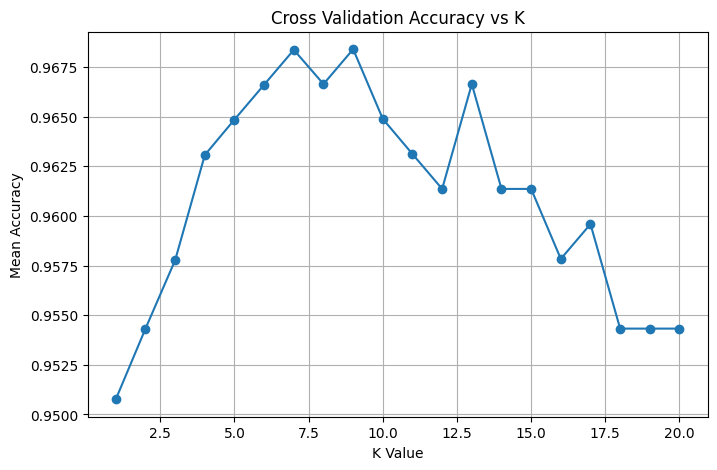

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(k_range,
         cv_scores,
         marker='o')

plt.xlabel("K Value")

plt.ylabel("Mean Accuracy")

plt.title("Cross Validation Accuracy vs K")

plt.grid(True)

plt.show()

In [43]:
best_cv_k = k_range[np.argmax(cv_scores)]

print("Best K using Cross Validation =", best_cv_k)

Best K using Cross Validation = 9


In [44]:
from sklearn.neighbors import KNeighborsClassifier

final_model = KNeighborsClassifier(n_neighbors=best_cv_k)

final_model.fit(X_train80, y_train80)

y_prob = final_model.predict_proba(X_test80)[:,1]

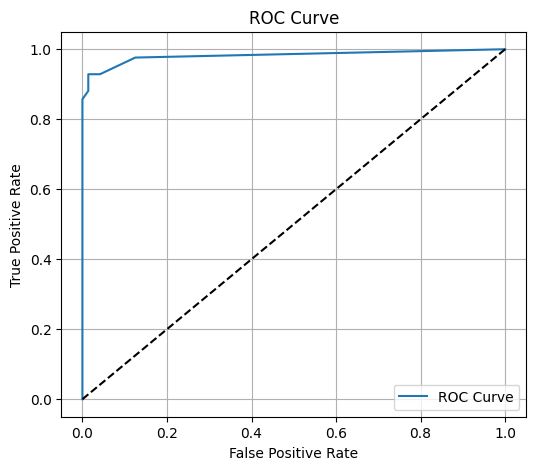

In [45]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, threshold = roc_curve(y_test80, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr,
         label="ROC Curve")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [46]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test80, y_prob)

print("AUC Score =", round(auc,4))

AUC Score = 0.9818
